<h1> Geometric Operations and Other Mathematical Tools with Pillow</h1>


Estimated time needed: **40** minutes


<h2> Spatial Operations in Image Processing</h2>


Spatial operations use  pixels in a neighborhood to determine the present pixel value. Some applications include filtering and sharpening. They are used in many steps in computer vision, such as segmentation, and are a key building block in Artificial Intelligence algorithms.


- Linear Filtering
    - Filtering Noise
    - Gaussian Blur
    - Image Sharpening
- Edges
- Median


* * *


Download the images for the lab


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/cameraman.jpeg
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png   

'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.


We will import the following libraries


In [ ]:
# Dùng để hiển thị hình ảnh
import matplotlib.pyplot as plt
# Dùng để tải ảnh
from PIL import Image
# Dùng để tạo kernel cho việc lọc ảnh
import numpy as np

This function will plot two images side by side 


In [ ]:
# Hàm hiển thị 2 ảnh để so sánh (ảnh gốc và ảnh sau khi xử lý)
def plot_image(image_1, image_2,title_1="Orignal",title_2="New Image"):
    plt.figure(figsize=(10,10))
    plt.subplot(1, 2, 1)
    plt.imshow(image_1)
    plt.title(title_1)
    plt.subplot(1, 2, 2)
    plt.imshow(image_2)
    plt.title(title_2)
    plt.show()

Spatial operations use the neighboring pixels to determine the present pixel value 


## Linear  Filtering


Filtering involves enhancing an image, for example, removing the noise from an image. Noise can be caused by a bad camera or bad image compression. The same factors that cause noise may lead to blurry images. We can apply filters to sharpen these images. Convolution is a standard way to filter an image. The filter is called the kernel and different kernels perform different tasks. In addition, Convolution is used for many of the most advanced artificial intelligence algorithms. We simply take the dot product of the kernel and an equally-sized portion of the image. We then shift the kernel and repeat.


Consider the following image:


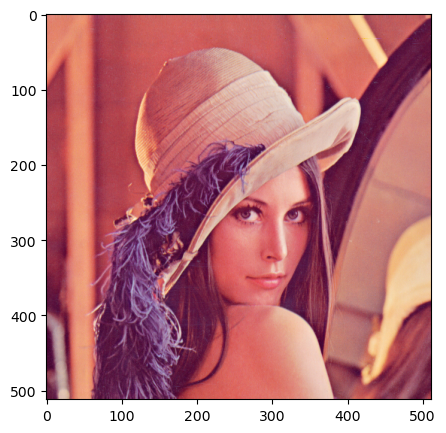

In [ ]:
# Tải ảnh từ file đã chỉ định
image = Image.open("lenna.png")
# Hiển thị ảnh
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.show()

The images we are working with are comprised of RGB values, which are values from 0 to 255. Zero means white noise, this makes the image look grainy:


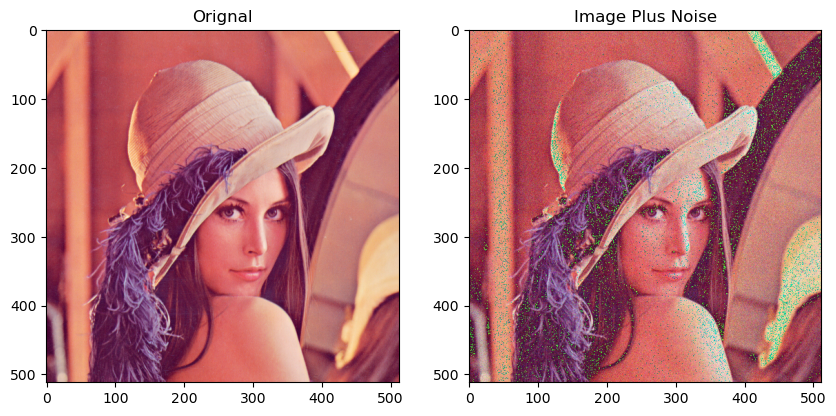

In [ ]:
# Lấy số hàng và số cột của ảnh
rows, cols = image.size
# Tạo nhiễu theo phân phối chuẩn với trung bình 0 và độ lệch chuẩn 15, sau đó chuyển sang kiểu uint8 (giá trị từ 0 đến 255)
noise = np.random.normal(0,15,(rows,cols,3)).astype(np.uint8)
# Thêm nhiễu vào ảnh
noisy_image = image + noise
# Tạo một ảnh PIL từ mảng dữ liệu
noisy_image = Image.fromarray(noisy_image)
# Hiển thị ảnh gốc và ảnh có nhiễu bằng hàm đã định nghĩa ở trên
plot_image(image, noisy_image, title_1="Orignal", title_2="Image Plus Noise")

When adding noise to an image sometimes the value might be greater than 255, in this case 256, is subtracted from the value to wrap the number around keeping it between 0 and 255. For example, consider an image with an RGB value of 137 and we add noise with an RGB value of 215 to get an RGB value of 352. We then subtract 256, the total number of possible values between 0 and 255, to get a number between 0 and 255.


### Filtering Noise


To be able to create customer kernels and use predefined filters we must import the following library


In [6]:
from PIL import ImageFilter

Smoothing filters average out the Pixels within a neighborhood, they are sometimes called low pass filters. For mean filtering, the  kernel simply averages out the kernels in a neighborhood.


In [ ]:
# Tạo kernel kích thước 5x5 trong đó mỗi giá trị là 1/36
kernel = np.ones((5,5))/36
# Tạo bộ lọc ImageFilter Kernel bằng cách cung cấp kích thước kernel và kernel đã được làm phẳng
kernel_filter = ImageFilter.Kernel((5,5), kernel.flatten())

The function <code>filter</code> performs a convolution between the image and the kernel on each color channel independently.


In [ ]:
# Lọc ảnh bằng kernel đã tạo
image_filtered = noisy_image.filter(kernel_filter)

We can plot the image before and after the filtering. We see the noise is reduced, but the image is blurry:


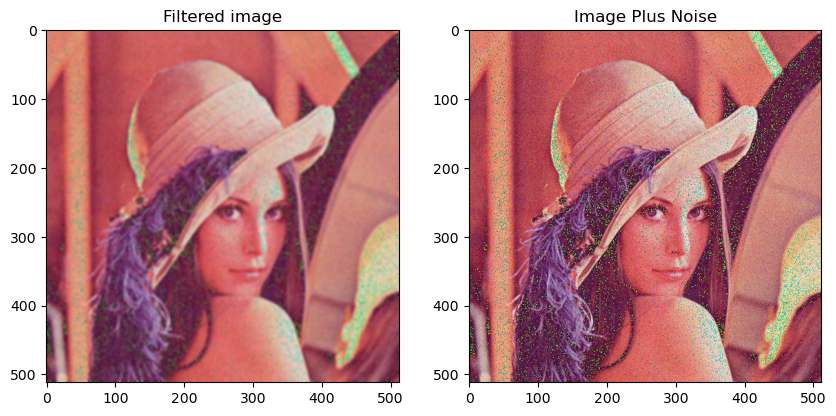

In [ ]:
# Hiển thị ảnh đã lọc và ảnh có nhiễu bằng hàm đã định nghĩa ở trên
plot_image(image_filtered, noisy_image,title_1="Filtered image",title_2="Image Plus Noise")

A smaller kernel keeps the image sharp, but filters less noise, here we try a 3x3 kernel. You can see her shoulders are sharper in this image but the green noise is brighter than the filtered image above.


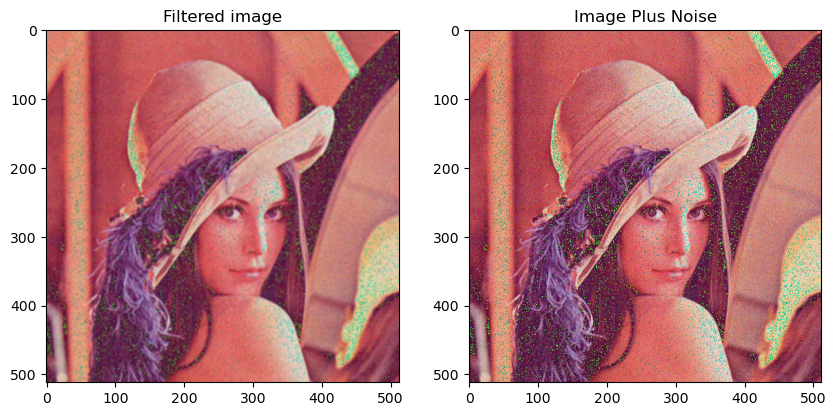

In [ ]:
# Tạo kernel kích thước 3x3 trong đó mỗi giá trị là 1/36
kernel = np.ones((3,3))/36
# Tạo bộ lọc ImageFilter Kernel bằng cách cung cấp kích thước kernel và kernel đã được làm phẳng
kernel_filter = ImageFilter.Kernel((3,3), kernel.flatten())
# Lọc ảnh bằng kernel đã tạo
image_filtered = noisy_image.filter(kernel_filter)
# Hiển thị ảnh đã lọc và ảnh có nhiễu bằng hàm đã định nghĩa ở trên
plot_image(image_filtered, noisy_image,title_1="Filtered image",title_2="Image Plus Noise")

### Gaussian Blur


To perform Gaussian Blur we use the `filter` function on an image using the predefined filter `ImageFilter.GaussianBlur`


Parameters

<p><code>radius</code>: blur kernel radius, default 2</p>


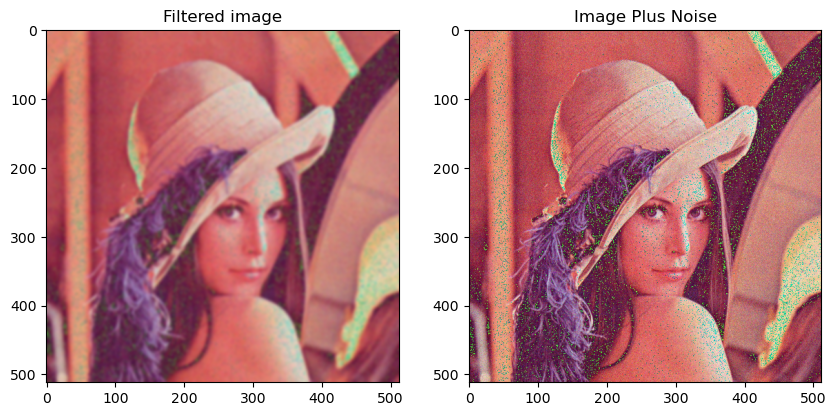

In [ ]:
# Lọc ảnh bằng bộ lọc GaussianBlur
image_filtered = noisy_image.filter(ImageFilter.GaussianBlur)
# Hiển thị ảnh đã lọc và ảnh nhiễu chưa lọc
plot_image(image_filtered , noisy_image,title_1="Filtered image",title_2="Image Plus Noise")

Lets try using a 4 by 4 kernel


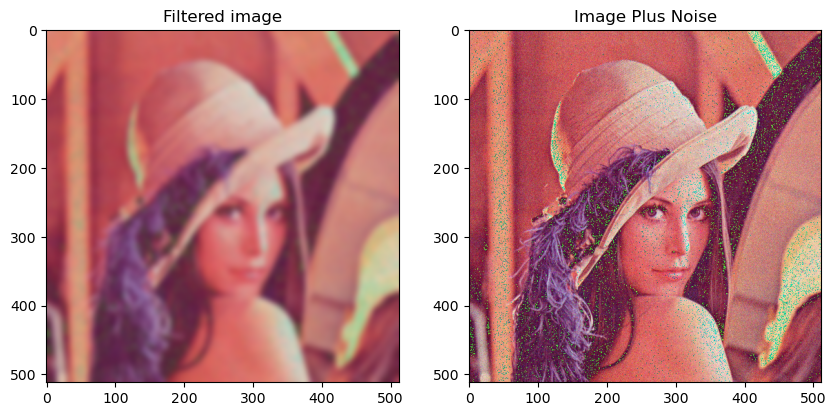

In [ ]:
# Lọc ảnh bằng GaussianBlur với kernel kích thước 4 trên ảnh có nhiễu
image_filtered = noisy_image.filter(ImageFilter.GaussianBlur(4))
# Hiển thị ảnh đã lọc và ảnh nhiễu chưa lọc
plot_image(image_filtered , noisy_image,title_1="Filtered image",title_2="Image Plus Noise")

### Image Sharpening


Image Sharpening involves smoothing the image and calculating the derivatives.  We can accomplish image sharpening by applying the following Kernel.


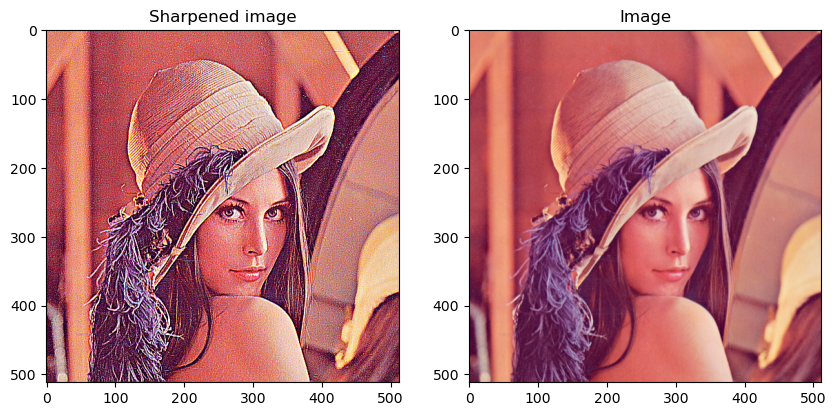

In [ ]:
# Kernel thường dùng để làm sắc nét ảnh
kernel = np.array([[-1,-1,-1], 
                   [-1, 9,-1],
                   [-1,-1,-1]])
kernel = ImageFilter.Kernel((3,3), kernel.flatten())
# Áp dụng bộ lọc làm sắc nét bằng kernel lên ảnh gốc (không có nhiễu)
sharpened = image.filter(kernel)
# Hiển thị ảnh đã làm sắc nét và ảnh gốc không có nhiễu
plot_image(sharpened , image, title_1="Sharpened image",title_2="Image")

We can also sharpen using a predefined filter


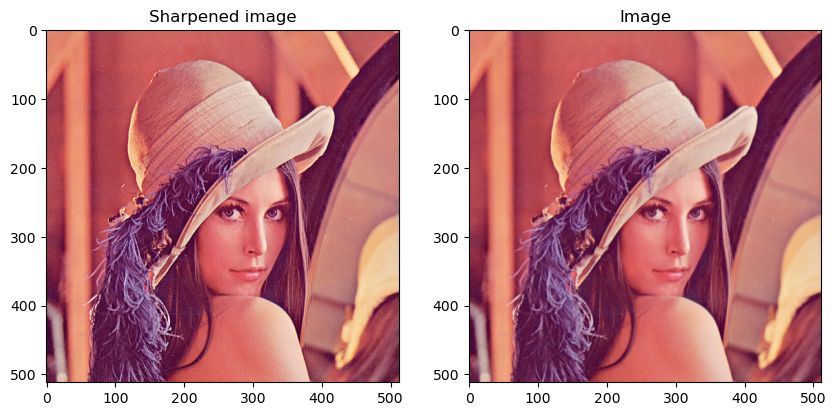

In [ ]:
# Làm sắc nét ảnh bằng bộ lọc có sẵn trong PIL
sharpened = image.filter(ImageFilter.SHARPEN)
# Hiển thị ảnh đã làm sắc nét và ảnh gốc không có nhiễu
plot_image(sharpened , image, title_1="Sharpened image",title_2="Image")

## Edges


Edges are where pixel intensities change. The Gradient of a function outputs the rate of change; we can approximate the gradient of a grayscale image with convolution. Consider the following image:


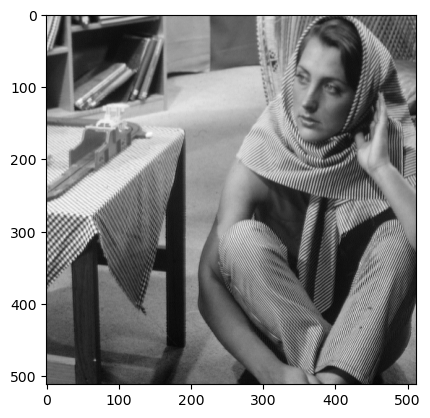

In [ ]:
# Tải ảnh từ file đã chỉ định
img_gray = Image.open('barbara.png')
# Hiển thị ảnh từ mảng dữ liệu, lưu ý ảnh có 2 chiều thay vì 3 chiều vì không có màu
plt.imshow(img_gray ,cmap='gray')

We enhance the edges so they are better picked up when we use edge detection


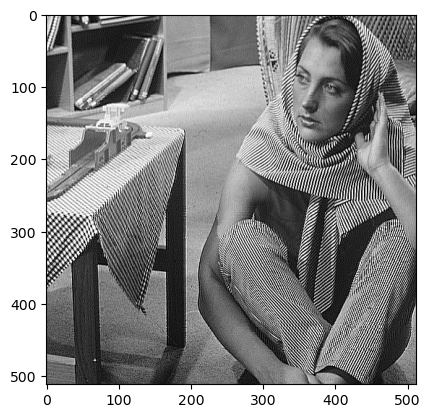

In [ ]:
# Lọc ảnh bằng bộ lọc EDGE_ENHANCE để tăng cường biên
img_gray = img_gray.filter(ImageFilter.EDGE_ENHANCE)
# Hiển thị ảnh sau khi tăng cường biên
plt.imshow(img_gray ,cmap='gray')

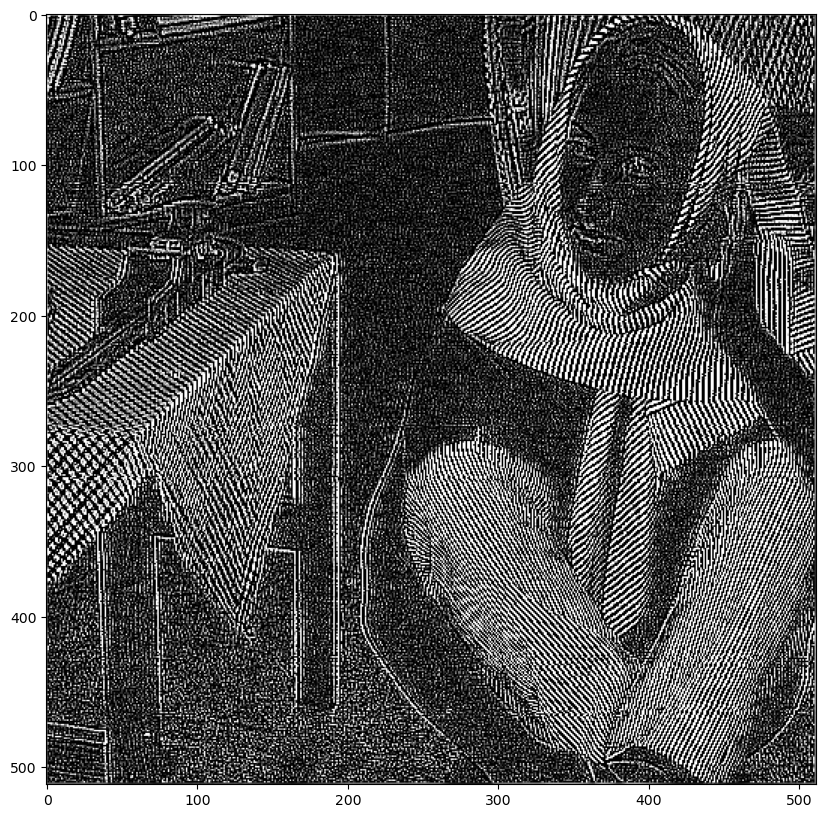

In [ ]:
# Lọc ảnh bằng bộ lọc FIND_EDGES để phát hiện các cạnh
img_gray = img_gray.filter(ImageFilter.FIND_EDGES)
# Hiển thị ảnh sau khi lọc
plt.figure(figsize=(10,10))
plt.imshow(img_gray ,cmap='gray')

## Median

Median filters find the median of all the pixels under the kernel area and the central element is replaced with this median value. 


We can apply median filters to regular images but let’s see how we can use a median filter to improve segmentation. Consider the cameraman example: 


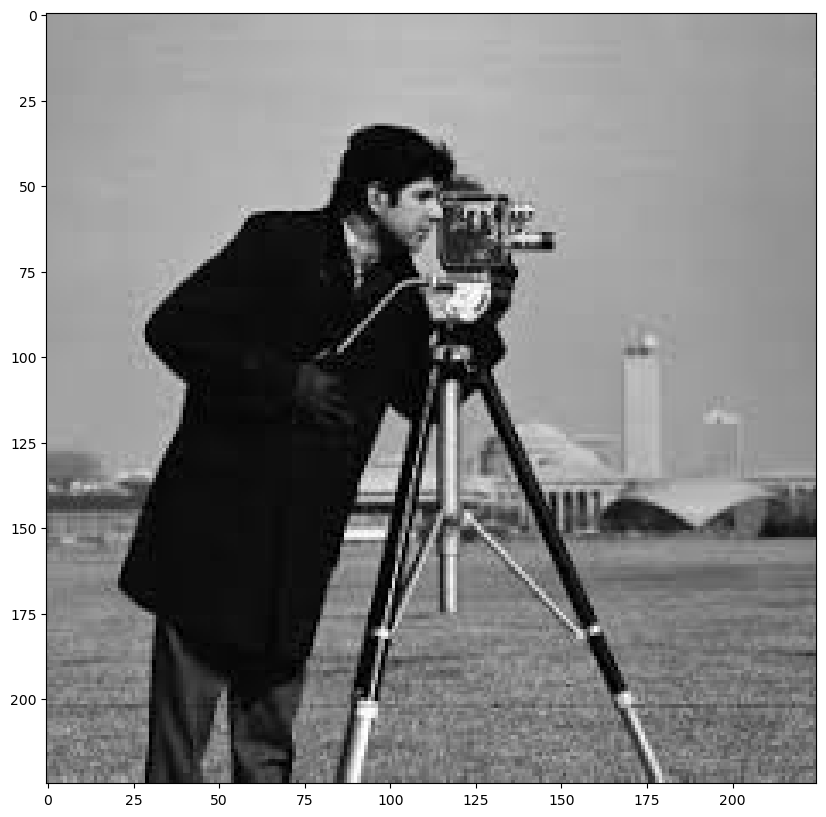

In [ ]:
# Tải ảnh cameraman
image = Image.open("cameraman.jpeg")
# Phóng to kích thước hiển thị của ảnh
plt.figure(figsize=(10,10))
# Hiển thị ảnh
plt.imshow(image,cmap="gray")

Median filtering blurs the background, increasing the segmentation between the cameraman and the background


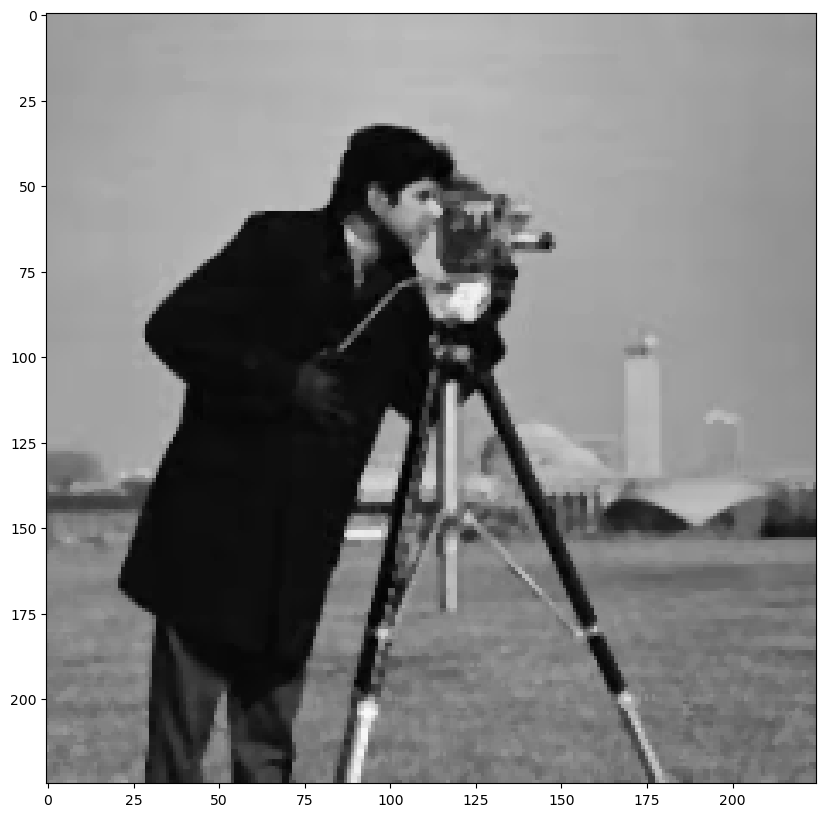

In [ ]:
# Lọc ảnh bằng bộ lọc MedianFilter
image = image.filter(ImageFilter.MedianFilter)
plt.figure(figsize=(10,10))
# Hiển thị ảnh
plt.imshow(image,cmap="gray")

# References


[1]  Images were taken from: [https://homepages.cae.wisc.edu/~ece533/images/](https://homepages.cae.wisc.edu/~ece533/images/?utm_email=Email&utm_source=Nurture&utm_content=000026UJ&utm_term=10006555&utm_campaign=PLACEHOLDER&utm_id=SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-CV0101EN-Coursera-25797139)

[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.
